# Fase 3: Preparación y Modelado de Datos
**Proyecto:** Business Intelligence — E-commerce  
**Dataset:** US Superstore  
**Curso:** Análisis de Datos — ITM 2026-1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

Matplotlib is building the font cache; this may take a moment.


## Carga del dataset

In [8]:
try:
    from google.colab import files
    print('Haz clic en "Elegir archivos" y selecciona tu dataset Superstore (.csv o .xlsx)')
    uploaded = files.upload()

    filename = list(uploaded.keys())[0]
    print(f'Archivo cargado: {filename}')

    if filename.endswith('.xlsx') or filename.endswith('.xls'):
        df = pd.read_excel(filename)
    else:
        df = pd.read_csv(filename, encoding='latin1')

except ModuleNotFoundError:
    import tkinter as tk
    from tkinter import filedialog

    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)

    filepath = filedialog.askopenfilename(
        title='Selecciona el archivo Superstore',
        filetypes=[
            ('Archivos CSV',   '*.csv'),
            ('Archivos Excel', '*.xlsx *.xls'),
            ('Todos',          '*.*')
        ]
    )
    root.destroy()

    if not filepath:
        raise FileNotFoundError('No seleccionaste ningún archivo. Vuelve a ejecutar la celda.')

    print(f'Archivo seleccionado: {filepath}')

    if filepath.endswith('.xlsx') or filepath.endswith('.xls'):
        df = pd.read_excel(filepath)
    else:
        df = pd.read_csv(filepath, encoding='latin1')

print(f'\nDataset cargado {df.shape[0]} filas, {df.shape[1]} columnas')
df.head()

Archivo seleccionado: C:/Users/ALEJANDRA/Downloads/US-Superstore-data.csv

Dataset cargado 9994 filas, 21 columnas


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Exploración inicial

In [9]:
print('Tipos de datos')
print(df.dtypes)
print()

print('Valores nulos')
print(df.isnull().sum())
print()

print('Estadísticas básicas')
df.describe()

Tipos de datos
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Valores nulos
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Estadísticas básic

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## Limpieza de datos

In [10]:
# 4.1 Eliminar duplicados
antes = df.shape[0]
df = df.drop_duplicates()
print(f'Duplicados eliminados: {antes - df.shape[0]}')

# 4.2 Convertir fechas
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])
print('Fechas convertidas')

# 4.3 Verificar ventas negativas
print(f'Ventas negativas: {df[df["Sales"] < 0].shape[0]}')

# 4.4 Rango de descuentos (debe estar entre 0 y 1)
print(f'Rango de Discount: {df["Discount"].min()} — {df["Discount"].max()}')

print('\nLimpieza completada')

Duplicados eliminados: 0
Fechas convertidas
Ventas negativas: 0
Rango de Discount: 0.0 — 0.8

Limpieza completada


## 5. Transformación y creación de variables

In [11]:
# Variables de tiempo
df['Year']       = df['Order Date'].dt.year
df['Month']      = df['Order Date'].dt.month
df['Quarter']    = df['Order Date'].dt.quarter
df['Month_Name'] = df['Order Date'].dt.strftime('%B')

# Días de envío
df['Days_to_Ship'] = (df['Ship Date'] - df['Order Date']).dt.days

# Margen de utilidad (%)
df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100
df['Profit_Margin'] = df['Profit_Margin'].replace([np.inf, -np.inf], np.nan)

# Categoría de descuento
df['Discount_Category'] = pd.cut(
    df['Discount'],
    bins=[-0.01, 0, 0.2, 0.4, 1.0],
    labels=['Sin descuento', 'Bajo (1-20%)', 'Medio (21-40%)', 'Alto (>40%)']
)

# Etiqueta de rentabilidad
df['Es_Rentable'] = df['Profit'].apply(lambda x: 'Rentable' if x > 0 else 'Pérdida')

print('Variables creadas')
df[['Year','Month','Quarter','Days_to_Ship','Profit_Margin','Discount_Category','Es_Rentable']].head()

Variables creadas


,Year,Month,Quarter,Days_to_Ship,Profit_Margin,Discount_Category,Es_Rentable
0,2016,11,4,3,16.00,Sin descuento,Rentable
1,2016,11,4,3,30.00,Sin descuento,Rentable
2,2016,6,2,4,47.00,Sin descuento,Rentable
3,2015,10,4,7,-40.00,Alto (>40%),Pérdida
4,2015,10,4,7,11.25,Bajo (1-20%),Rentable


## 6. Selección de variables

In [12]:
dimensiones = ['Order ID', 'Customer ID', 'Customer Name', 'Segment',
               'Region', 'State', 'City', 'Category', 'Sub-Category',
               'Product Name', 'Ship Mode', 'Year', 'Month',
               'Quarter', 'Discount_Category', 'Es_Rentable']

metricas = ['Sales', 'Profit', 'Quantity', 'Discount',
            'Profit_Margin', 'Days_to_Ship']

print('DIMENSIONES:', dimensiones)
print()
print('HECHOS:', metricas)

DIMENSIONES: ['Order ID', 'Customer ID', 'Customer Name', 'Segment', 'Region', 'State', 'City', 'Category', 'Sub-Category', 'Product Name', 'Ship Mode', 'Year', 'Month', 'Quarter', 'Discount_Category', 'Es_Rentable']

HECHOS: ['Sales', 'Profit', 'Quantity', 'Discount', 'Profit_Margin', 'Days_to_Ship']



## 7. Validación de hipótesis

Hipótesis 1: ¿Los descuentos afectan la utilidad?

H₀: No existe relación entre el descuento y la utilidad

H₁: A mayor descuento, menor utilidad

=== HIPÓTESIS 1: Descuento vs Utilidad ===
Correlación de Pearson (r): -0.2195
p-value:                    0.000000

Resultado: Se RECHAZA H₀ ✓
Interpretación: Existe correlación negativa significativa (r=-0.22). Los descuentos SÍ impactan la rentabilidad.


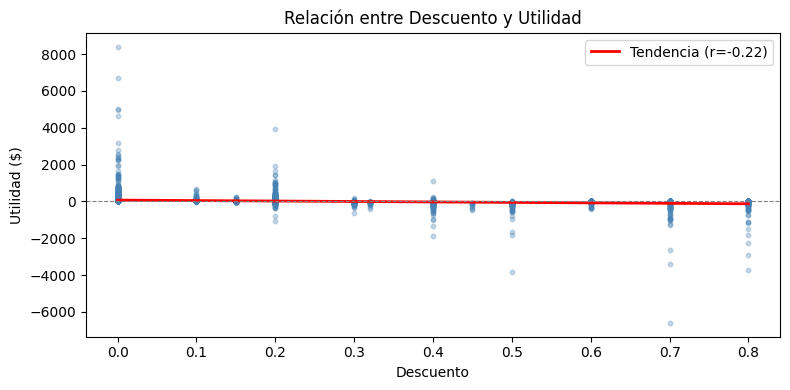

In [13]:
corr, p_value = stats.pearsonr(df['Discount'], df['Profit'])

print('=== HIPÓTESIS 1: Descuento vs Utilidad ===')
print(f'Correlación de Pearson (r): {corr:.4f}')
print(f'p-value:                    {p_value:.6f}')
print()

if p_value < 0.05:
    print('Resultado: Se RECHAZA H₀ ✓')
    print(f'Interpretación: Existe correlación {"negativa" if corr < 0 else "positiva"} '
          f'significativa (r={corr:.2f}). Los descuentos SÍ impactan la rentabilidad.')
else:
    print('Resultado: No se rechaza H₀')
    print('No hay evidencia suficiente de relación entre descuento y utilidad.')

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(df['Discount'], df['Profit'], alpha=0.3, s=10, color='steelblue')
m, b = np.polyfit(df['Discount'], df['Profit'], 1)
x_line = np.linspace(0, df['Discount'].max(), 100)
ax.plot(x_line, m * x_line + b, color='red', linewidth=2, label=f'Tendencia (r={corr:.2f})')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Descuento')
ax.set_ylabel('Utilidad ($)')
ax.set_title('Relación entre Descuento y Utilidad')
ax.legend()
plt.tight_layout()
plt.savefig('h1_descuento_utilidad.png', dpi=150)
plt.show()

Hipótesis 2: ¿La utilidad varía entre regiones?

H₀: No hay diferencia significativa en la utilidad promedio entre regiones

H₁: Al menos una región tiene utilidad promedio significativamente diferente

=== HIPÓTESIS 2: Utilidad por Región ===
F-estadístico: 2.6225
p-value:       0.048892

Utilidad promedio por región:
Region
Central    17.09
East       32.14
South      28.86
West       33.85

Resultado: Se RECHAZA H₀ ✓
Hay diferencia significativa entre al menos dos regiones.

--- Test Post-hoc de Tukey ---
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1 group2 meandiff p-adj   lower    upper  reject
------------------------------------------------------
Central   East  15.0431 0.0986  -1.7808  31.867  False
Central  South   11.765 0.4065   -7.714  31.244  False
Central   West  16.7563  0.043   0.3566 33.1561   True
   East  South  -3.2781 0.9697  -22.005 15.4487  False
   East   West   1.7132  0.992 -13.7857 17.2121  False
  South   West   4.9914 0.8975 -13.3553 23.3381  False
------------------------------------------------------


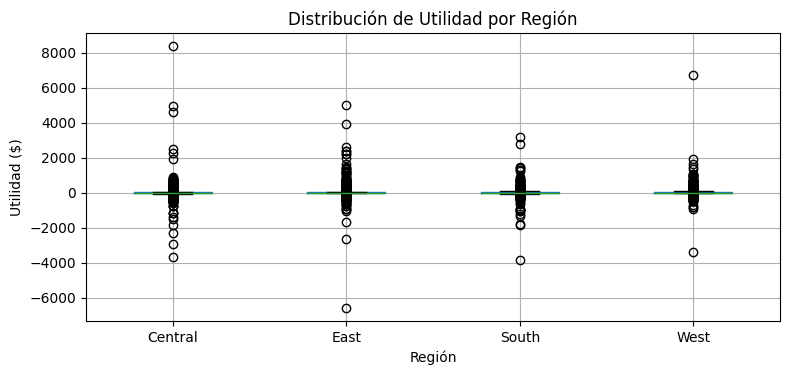

In [14]:
grupos_region = [df[df['Region'] == r]['Profit'].values for r in df['Region'].unique()]
f_stat, p_value = stats.f_oneway(*grupos_region)

print('=== HIPÓTESIS 2: Utilidad por Región ===')
print(f'F-estadístico: {f_stat:.4f}')
print(f'p-value:       {p_value:.6f}')
print()
print('Utilidad promedio por región:')
print(df.groupby('Region')['Profit'].mean().round(2).to_string())
print()

if p_value < 0.05:
    print('Resultado: Se RECHAZA H₀ ✓')
    print('Hay diferencia significativa entre al menos dos regiones.')
    print()
    print('--- Test Post-hoc de Tukey ---')
    tukey = pairwise_tukeyhsd(endog=df['Profit'], groups=df['Region'], alpha=0.05)
    print(tukey)
else:
    print('Resultado: No se rechaza H₀')

fig, ax = plt.subplots(figsize=(8, 4))
df.boxplot(column='Profit', by='Region', ax=ax)
ax.set_title('Distribución de Utilidad por Región')
ax.set_xlabel('Región')
ax.set_ylabel('Utilidad ($)')
plt.suptitle('')
plt.tight_layout()
plt.savefig('h2_utilidad_region.png', dpi=150)
plt.show()

Hipótesis 3: ¿Tecnología es la categoría más rentable?

H₀: No hay diferencia en la utilidad promedio entre categorías

H₁: Technology tiene utilidad promedio significativamente mayor

=== HIPÓTESIS 3: Utilidad por Categoría ===
F-estadístico: 54.3110
p-value:       0.000000

Utilidad promedio por categoría:
Category
Furniture           8.70
Office Supplies    20.33
Technology         78.75

Resultado: Se RECHAZA H₀ ✓

--- Test Post-hoc de Tukey ---
         Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1          group2     meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------
      Furniture Office Supplies  11.6277 0.1181 -2.1626 25.4181  False
      Furniture      Technology  70.0527    0.0  52.669 87.4364   True
Office Supplies      Technology   58.425    0.0 43.8977 72.9522   True
----------------------------------------------------------------------


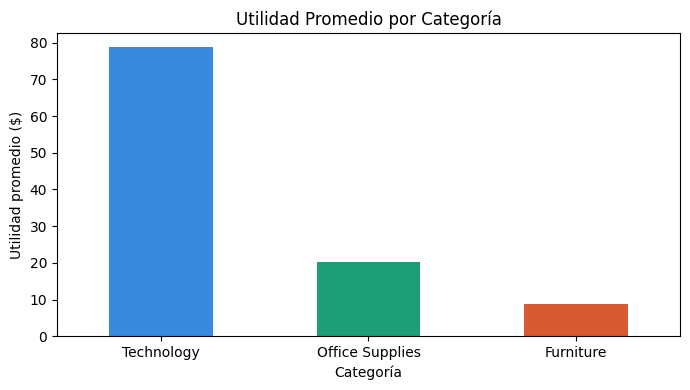

In [15]:
grupos_cat = [df[df['Category'] == c]['Profit'].values for c in df['Category'].unique()]
f_stat, p_value = stats.f_oneway(*grupos_cat)

print('=== HIPÓTESIS 3: Utilidad por Categoría ===')
print(f'F-estadístico: {f_stat:.4f}')
print(f'p-value:       {p_value:.6f}')
print()
print('Utilidad promedio por categoría:')
print(df.groupby('Category')['Profit'].mean().round(2).to_string())
print()

if p_value < 0.05:
    print('Resultado: Se RECHAZA H₀ ✓')
    print()
    print('--- Test Post-hoc de Tukey ---')
    tukey = pairwise_tukeyhsd(endog=df['Profit'], groups=df['Category'], alpha=0.05)
    print(tukey)
else:
    print('Resultado: No se rechaza H₀')

fig, ax = plt.subplots(figsize=(7, 4))
resumen = df.groupby('Category')['Profit'].mean().sort_values(ascending=False)
resumen.plot(kind='bar', ax=ax, color=['#378ADD', '#1D9E75', '#D85A30'])
ax.set_title('Utilidad Promedio por Categoría')
ax.set_xlabel('Categoría')
ax.set_ylabel('Utilidad promedio ($)')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('h3_utilidad_categoria.png', dpi=150)
plt.show()

8. Resumen de hipótesis

In [16]:
# H1: Pearson
corr, p_value_h1 = stats.pearsonr(df['Discount'], df['Profit'])

# H2: ANOVA por región
anova_h2 = stats.f_oneway(
    df[df['Region']=='East']['Profit'],
    df[df['Region']=='West']['Profit'],
    df[df['Region']=='Central']['Profit'],
    df[df['Region']=='South']['Profit']
)

p_value_h2 = anova_h2.pvalue

# H3: ANOVA por categoría (rentabilidad)
anova_h3 = stats.f_oneway(
    df[df['Category']=='Technology']['Profit'],
    df[df['Category']=='Furniture']['Profit'],
    df[df['Category']=='Office Supplies']['Profit']
)

p_value_h3 = anova_h3.pvalue

print('p-value H3:', p_value_h3)

resumen = pd.DataFrame({
    'Hipótesis': [
        'H1: Descuento afecta la utilidad',
        'H2: La utilidad varía por región',
        'H3: Existen diferencias de utilidad entre categorías'
    ],
    'Test aplicado': ['Pearson', 'ANOVA + Tukey', 'ANOVA + Tukey'],
    'p-value': [p_value_h1, p_value_h2, p_value_h3],
    'Decisión': [
        'Rechazar H0' if p_value_h1 < 0.05 else 'No rechazar H0',
        'Rechazar H0' if p_value_h2 < 0.05 else 'No rechazar H0',
        'Rechazar H0' if p_value_h3 < 0.05 else 'No rechazar H0'
    ]
})

resumen

p-value H3: 3.469918346218076e-24


,Hipótesis,Test aplicado,p-value,Decisión
0,H1: Descuento afecta la utilidad,Pearson,2.702294e-109,Rechazar H0
1,H2: La utilidad varía por región,ANOVA + Tukey,4.889160e-02,Rechazar H0
2,H3: Existen diferencias de utilidad entre cate...,ANOVA + Tukey,3.469918e-24,Rechazar H0
